# Lab 3 plots 

       LINEAR FIT RESULTS: T = rho_L * v^2 + b

D-String (26 gauge)
  Slope (rho_L from fit) = 0.001576 ± 0.000088 kg/m
  Intercept              = 3.2687 N
  Direct rho_L           = 0.001700 ± 0.000500 kg/m

Low E-String (46 gauge)
  Slope (rho_L from fit) = 0.005540 ± 0.000111 kg/m
  Intercept              = -1.5901 N
  Direct rho_L           = 0.006500 ± 0.000500 kg/m

           AGREEMENT CHECK

  D-String : |0.001576 - 0.001700| = 0.000124  vs  combined unc = 0.000588  -->  ✅ AGREE within uncertainty!

  Low E-String: |0.005540 - 0.006500| = 0.000960  vs  combined unc = 0.000611  -->  ❌ DO NOT agree within uncertainty.

       MUSICAL NOTES AT EACH TENSION

D-String (26 gauge)
  Mass(kg)   Tension(N)   Freq(Hz)     Note     Cents Off
  1.0        9.8          41.7         E1       +22.1
  2.0        19.6         56.3         A1       +41.3
  3.0        29.4         71.0         C#2      +43.0
  4.0        39.2         85.6         F2       -33.5
  5.0        49.1         98.4     

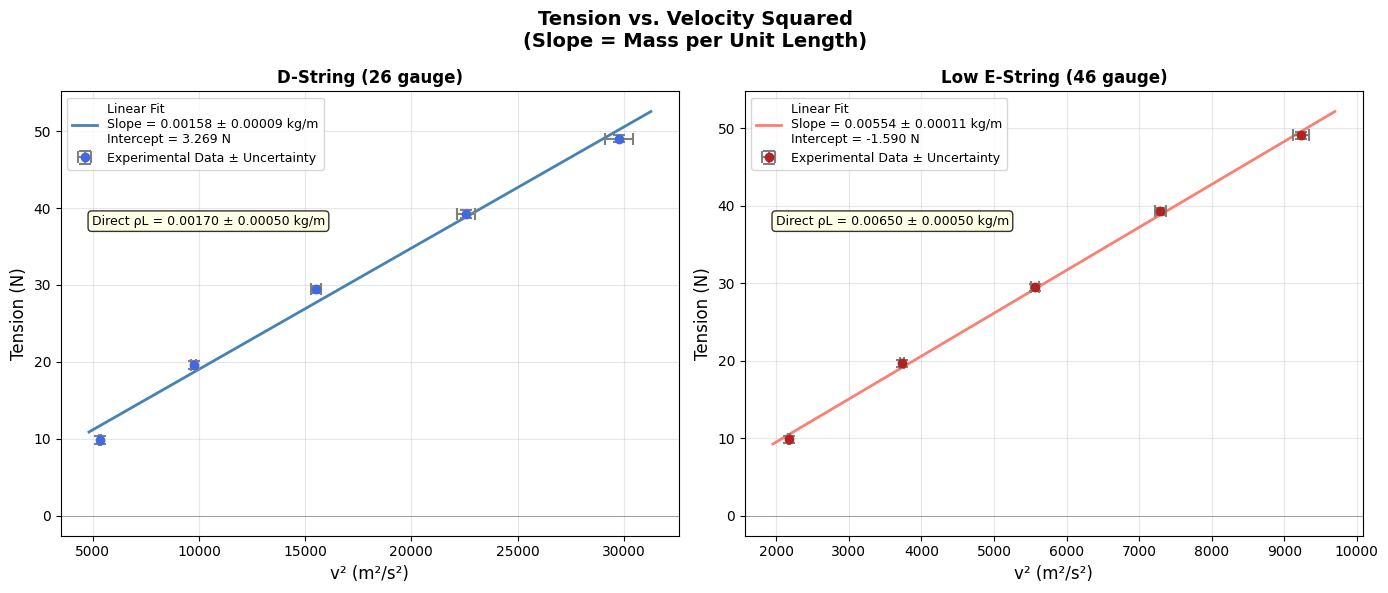

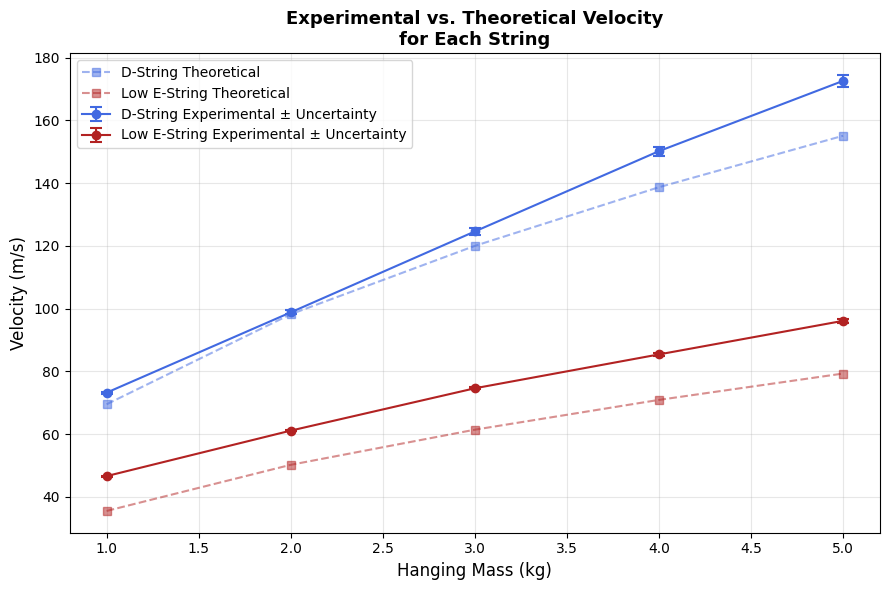

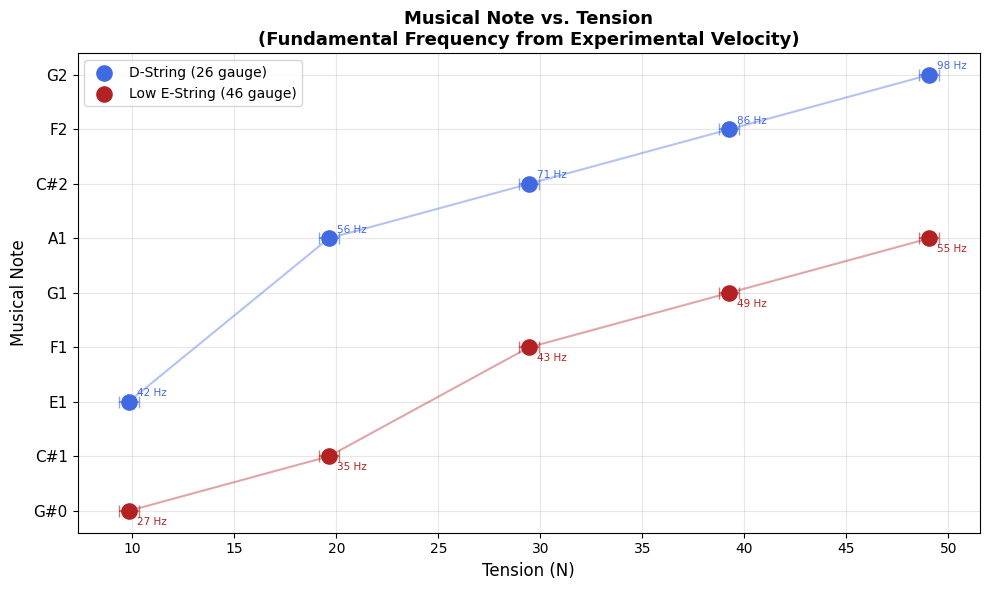


✅ All plots saved to Lab_3 folder!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ============================================================
# DATA LOADING
# ============================================================
df = pd.read_csv(r"c:\Users\hogwi\OneDrive - University of Central Arkansas\Acoustics_ElectroMag\Spring-Acoustics---ElectroMag2\Acoustics\Lab_3\Lab-3-data.csv")

# Separate strings
d_string = df[df['String Type'] == 'D-String'].copy()
e_string = df[df['String Type'] == 'Low E-String'].copy()

# ============================================================
# CONSTANTS & SETUP
# ============================================================
g = 9.81  # m/s^2
L_string = 0.877  # m (string length / distance to bridge)

# Direct mass per unit length measurements (kg/m)
rho_D_direct = 0.0017   # kg/m
rho_E_direct = 0.0065   # kg/m

# Uncertainty: assume ±0.0001 kg/m for direct measurement
rho_D_direct_unc = 0.0005
rho_E_direct_unc = 0.0005

# ============================================================
# COMPUTE v^2 AND TENSION
# ============================================================
for data in [d_string, e_string]:
    data['v_exp'] = data['Average Velocity (d/t) (m/s)']
    data['v2_exp'] = data['v_exp'] ** 2
    data['v_theory'] = data['Theoretical Velocity (sqrt(T/u)) (m/s)']
    data['v2_theory'] = data['v_theory'] ** 2
    data['Tension_N'] = data['Mass (kg)'] * g

# ============================================================
# LINEAR REGRESSION: T vs v^2
# ============================================================
def fit_line(v2, T):
    slope, intercept, r, p, se = linregress(v2, T)
    return slope, intercept, se

slope_D, intercept_D, se_D = fit_line(d_string['v2_exp'], d_string['Tension_N'])
slope_E, intercept_E, se_E = fit_line(e_string['v2_exp'], e_string['Tension_N'])

print("=" * 55)
print("       LINEAR FIT RESULTS: T = rho_L * v^2 + b")
print("=" * 55)
print(f"\n{'D-String (26 gauge)':}")
print(f"  Slope (rho_L from fit) = {slope_D:.6f} ± {se_D:.6f} kg/m")
print(f"  Intercept              = {intercept_D:.4f} N")
print(f"  Direct rho_L           = {rho_D_direct:.6f} ± {rho_D_direct_unc:.6f} kg/m")

print(f"\n{'Low E-String (46 gauge)':}")
print(f"  Slope (rho_L from fit) = {slope_E:.6f} ± {se_E:.6f} kg/m")
print(f"  Intercept              = {intercept_E:.4f} N")
print(f"  Direct rho_L           = {rho_E_direct:.6f} ± {rho_E_direct_unc:.6f} kg/m")

# ============================================================
# AGREEMENT CHECK
# ============================================================
def check_agreement(val1, unc1, val2, unc2, name):
    diff = abs(val1 - val2)
    combined_unc = unc1 + unc2
    if diff <= combined_unc:
        result = "✅ AGREE within uncertainty!"
    else:
        result = "❌ DO NOT agree within uncertainty."
    print(f"\n  {name}: |{val1:.6f} - {val2:.6f}| = {diff:.6f}  vs  combined unc = {combined_unc:.6f}  -->  {result}")

print("\n" + "=" * 55)
print("           AGREEMENT CHECK")
print("=" * 55)
check_agreement(slope_D, se_D, rho_D_direct, rho_D_direct_unc, "D-String ")
check_agreement(slope_E, se_E, rho_E_direct, rho_E_direct_unc, "Low E-String")

# ============================================================
# MUSICAL NOTE FINDER
# ============================================================
# f = v / (2L) for fundamental frequency on a string
# Note frequencies based on A4 = 440 Hz equal temperament
NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F',
              'F#', 'G', 'G#', 'A', 'A#', 'B']

def freq_to_note(freq):
    """Convert frequency to nearest musical note with octave."""
    if freq <= 0:
        return "N/A", 0
    A4 = 440.0
    semitones = 12 * np.log2(freq / A4)
    midi = round(semitones) + 69  # MIDI note number
    note_idx = midi % 12
    octave = (midi // 12) - 1
    note_name = NOTE_NAMES[note_idx]
    # Exact frequency of nearest note
    note_freq = A4 * 2 ** ((midi - 69) / 12)
    cents_off = 1200 * np.log2(freq / note_freq)
    return f"{note_name}{octave}", cents_off

# Compute fundamental frequencies using experimental velocity
# f = v / (2L)  -- fundamental mode
for data in [d_string, e_string]:
    data['fund_freq'] = data['v_exp'] / (2 * L_string)
    data['note'] = data['fund_freq'].apply(lambda f: freq_to_note(f)[0])
    data['cents_off'] = data['fund_freq'].apply(lambda f: freq_to_note(f)[1])

print("\n" + "=" * 55)
print("       MUSICAL NOTES AT EACH TENSION")
print("=" * 55)
print(f"\n{'D-String (26 gauge)':}")
print(f"  {'Mass(kg)':<10} {'Tension(N)':<12} {'Freq(Hz)':<12} {'Note':<8} {'Cents Off'}")
for _, row in d_string.iterrows():
    print(f"  {row['Mass (kg)']:<10.1f} {row['Tension_N']:<12.1f} {row['fund_freq']:<12.1f} {row['note']:<8} {row['cents_off']:+.1f}")

print(f"\n{'Low E-String (46 gauge)':}")
print(f"  {'Mass(kg)':<10} {'Tension(N)':<12} {'Freq(Hz)':<12} {'Note':<8} {'Cents Off'}")
for _, row in e_string.iterrows():
    print(f"  {row['Mass (kg)']:<10.1f} {row['Tension_N']:<12.1f} {row['fund_freq']:<12.1f} {row['note']:<8} {row['cents_off']:+.1f}")

# ============================================================
# PLOT 1: T vs v^2 for both strings
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Tension vs. Velocity Squared\n(Slope = Mass per Unit Length)',
             fontsize=14, fontweight='bold')

datasets = [
    (d_string, slope_D, intercept_D, se_D, rho_D_direct, rho_D_direct_unc,
     'D-String (26 gauge)', 'royalblue', 'steelblue'),
    (e_string, slope_E, intercept_E, se_E, rho_E_direct, rho_E_direct_unc,
     'Low E-String (46 gauge)', 'firebrick', 'salmon'),
]

for ax, (data, slope, intercept, se, rho_dir, rho_dir_unc, title, color, fit_color) in zip(axes, datasets):
    v2 = data['v2_exp'].values
    T  = data['Tension_N'].values

    # Uncertainty in v^2: assume timing uncertainty of ±0.05 ms
    time_unc_ms = 0.05  # ms
    time_unc_s = time_unc_ms / 1000
    dist = data['String Length (m)'].values
    avg_time_s = data['Average Time (ms)'].values / 1000
    v_unc = dist * time_unc_s / avg_time_s**2          # dv = d * dt / t^2
    v2_unc = 2 * data['v_exp'].values * v_unc

    # Tension uncertainty: assume ±0.05 kg on hanging mass
    T_unc = 0.05 * g * np.ones(len(T))

    v2_fit = np.linspace(v2.min() * 0.9, v2.max() * 1.05, 200)
    T_fit  = slope * v2_fit + intercept

    ax.errorbar(v2, T, xerr=v2_unc, yerr=T_unc,
                fmt='o', color=color, ecolor='gray',
                elinewidth=1.5, capsize=4, capthick=1.5,
                zorder=5, label='Experimental Data ± Uncertainty')
    ax.plot(v2_fit, T_fit, color=fit_color, linewidth=2,
            label=f'Linear Fit\nSlope = {slope:.5f} ± {se:.5f} kg/m\nIntercept = {intercept:.3f} N')

    ax.set_xlabel('v² (m²/s²)', fontsize=12)
    ax.set_ylabel('Tension (N)', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.text(0.05, 0.70,
            f'Direct ρL = {rho_dir:.5f} ± {rho_dir_unc:.5f} kg/m',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(r"c:\Users\hogwi\OneDrive - University of Central Arkansas\Acoustics_ElectroMag\Spring-Acoustics---ElectroMag2\Acoustics\Lab_3\T_vs_v2.png", dpi=150)
plt.show()

# ============================================================
# PLOT 2: Experimental vs Theoretical Velocity
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Experimental vs. Theoretical Velocity\nfor Each String', fontsize=13, fontweight='bold')

masses = d_string['Mass (kg)'].values

# Velocity uncertainties for each string
avg_time_D = d_string['Average Time (ms)'].values / 1000
avg_time_E = e_string['Average Time (ms)'].values / 1000
dist_D = d_string['String Length (m)'].values
dist_E = e_string['String Length (m)'].values

v_unc_D = dist_D * time_unc_s / avg_time_D**2
v_unc_E = dist_E * time_unc_s / avg_time_E**2

ax.errorbar(masses, d_string['v_exp'], yerr=v_unc_D,
            fmt='o-', color='royalblue', ecolor='royalblue',
            elinewidth=1.5, capsize=4, capthick=1.5,
            label='D-String Experimental ± Uncertainty')
ax.plot(masses, d_string['v_theory'], 's--', color='royalblue',
        alpha=0.5, label='D-String Theoretical')

ax.errorbar(masses, e_string['v_exp'], yerr=v_unc_E,
            fmt='o-', color='firebrick', ecolor='firebrick',
            elinewidth=1.5, capsize=4, capthick=1.5,
            label='Low E-String Experimental ± Uncertainty')
ax.plot(masses, e_string['v_theory'], 's--', color='firebrick',
        alpha=0.5, label='Low E-String Theoretical')

ax.set_xlabel('Hanging Mass (kg)', fontsize=12)
ax.set_ylabel('Velocity (m/s)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r"c:\Users\hogwi\OneDrive - University of Central Arkansas\Acoustics_ElectroMag\Spring-Acoustics---ElectroMag2\Acoustics\Lab_3\velocity_comparison.png", dpi=150)
plt.show()

# ============================================================
# PLOT 3: Musical Notes vs Tension  🎵
# ============================================================
# Build a chromatic scale mapping for y-axis
all_notes = list(dict.fromkeys(
    list(d_string['note']) + list(e_string['note'])
))

# Get all unique notes and sort by frequency
def note_to_freq(note_str):
    name = note_str[:-1]
    octave = int(note_str[-1])
    idx = NOTE_NAMES.index(name)
    midi = (octave + 1) * 12 + idx
    return 440.0 * 2 ** ((midi - 69) / 12)

# Create a sorted list of all notes that appear
all_notes_sorted = sorted(
    set(list(d_string['note']) + list(e_string['note'])),
    key=note_to_freq
)
note_to_y = {n: i for i, n in enumerate(all_notes_sorted)}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Musical Note vs. Tension\n(Fundamental Frequency from Experimental Velocity)',
             fontsize=13, fontweight='bold')

# D-String
d_y = [note_to_y[n] for n in d_string['note']]
e_y = [note_to_y[n] for n in e_string['note']]

sc1 = ax.scatter(d_string['Tension_N'], d_y, s=120, color='royalblue',
                 zorder=5, label='D-String (26 gauge)')
ax.errorbar(d_string['Tension_N'], d_y, xerr=0.05 * g,
            fmt='none', ecolor='royalblue', elinewidth=1.5, capsize=4, alpha=0.6)
ax.plot(d_string['Tension_N'], d_y, color='royalblue', alpha=0.4)

sc2 = ax.scatter(e_string['Tension_N'], e_y, s=120, color='firebrick',
                 zorder=5, label='Low E-String (46 gauge)')
ax.errorbar(e_string['Tension_N'], e_y, xerr=0.05 * g,
            fmt='none', ecolor='firebrick', elinewidth=1.5, capsize=4, alpha=0.6)
ax.plot(e_string['Tension_N'], e_y, color='firebrick', alpha=0.4)

# Annotate each point with frequency
for _, row in d_string.iterrows():
    ax.annotate(f"{row['fund_freq']:.0f} Hz",
                (row['Tension_N'], note_to_y[row['note']]),
                textcoords='offset points', xytext=(6, 4), fontsize=7.5, color='royalblue')

for _, row in e_string.iterrows():
    ax.annotate(f"{row['fund_freq']:.0f} Hz",
                (row['Tension_N'], note_to_y[row['note']]),
                textcoords='offset points', xytext=(6, -10), fontsize=7.5, color='firebrick')

ax.set_xlabel('Tension (N)', fontsize=12)
ax.set_ylabel('Musical Note', fontsize=12)
ax.set_yticks(range(len(all_notes_sorted)))
ax.set_yticklabels(all_notes_sorted, fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='both')
plt.tight_layout()
plt.savefig(r"c:\Users\hogwi\OneDrive - University of Central Arkansas\Acoustics_ElectroMag\Spring-Acoustics---ElectroMag2\Acoustics\Lab_3\musical_notes.png", dpi=150)
plt.show()

print("\n✅ All plots saved to Lab_3 folder!")